In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import random

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/content/filtered_datasetf-Copy1.csv")
df

,COUNTRYNAME,Gender,Age,age_mh,Education,Household_Income,Subjective_Income,EMP_2010,Global11Regions,WorldBank_Income_Group,...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
0,United States,2,80,,2,5,2,6,9,4,...,4,5,3,3,3,2,5,1,4,2
1,United States,1,23,,3,4,1,1,9,4,...,2,2,3,4,2,2,3,1,1,4
2,United States,1,29,,3,4,1,1,9,4,...,5,1,1,2,5,2,5,1,3,4
3,United States,2,60,,3,4,2,1,9,4,...,4,4,2,2,2,5,3,1,1,1
4,United States,1,41,,2,2,4,6,9,4,...,3,2,5,1,3,3,4,1,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119083,Kosovo,2,27,,3,0,1,1,2,3,...,1,5,1,3,1,4,3,2,4,4
119084,Kosovo,2,24,2,3,0,2,6,2,3,...,1,1,4,4,3,2,4,1,5,2
119085,Kosovo,1,24,,3,0,1,2,2,3,...,4,3,2,1,1,1,3,2,5,2
119086,Kosovo,1,29,,3,0,2,1,2,3,...,5,2,3,5,5,2,1,2,5,3


In [ ]:
df3 = pd.read_csv("/content/FILTERED_MENTAL_HEALTH_DATASET.csv")
df3

,COUNTRYNEW,FIELD_DATE,YEAR_WAVE,Knowledge_about_Science,Trust_in_science,Tech_Impact_Local_Jobs_5Yrs,Health_Impact_of_ScienceA,Science_Explain_Emotions,WHO_based_decisions,Doctors_Based_Decisions,...,SM_Usage_Freq,HealthContent_on_SM,Science_vs_Religion_Belief\n,Age,Gender,Education,Per_capita_income,wbi,Income_Satisfaction,Employment_Status
0,United States,10-01-2020,2020,2,3,2,Mostly positive,1,4,2,...,less,Some of the time,Religion,80,Female,Secondary,5,4,Getting by on present income,Unemployed
1,United States,10-01-2020,2020,1,1,1,Mostly positive,1,1,1,...,Several times a day,Some of the time,,23,Male,University,4,4,Living comfortably,Employed
2,United States,10-01-2020,2020,1,1,1,Mostly positive,1,1,1,...,Almost every hour,Most of the time,,29,Male,University,4,4,Living comfortably,Employed
3,United States,10-01-2020,2020,2,2,2,No impact,3,1,1,...,less,Never,Science,60,Female,University,4,4,Getting by on present income,Employed
4,United States,10-01-2020,2020,3,1,3,Mostly positive,3,1,1,...,Several times as hour,Some of the time,,41,Male,Secondary,2,4,Very difficult,Unemployed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119083,Kosovo,12-01-2020,2020,2,2,2,Both,1,1,1,...,Several times a day,Some of the time,Religion,27,Female,University,5,3,Living comfortably,Employed
119084,Kosovo,12-01-2020,2020,2,2,3,No impact,3,1,0,...,,,Religion,24,Female,University,3,3,Getting by on present income,Unemployed
119085,Kosovo,12-01-2020,2020,1,2,2,Mostly positive,1,2,2,...,Several times a day,Some of the time,Religion,24,Male,University,5,3,Living comfortably,Self Employed
119086,Kosovo,12-01-2020,2020,3,1,2,Mostly negative,2,1,2,...,Several times a day,Most of the time,Religion,29,Male,University,5,3,Getting by on present income,Employed


In [ ]:
df.head()

,COUNTRYNAME,Gender,Age,age_mh,Education,Household_Income,Subjective_Income,EMP_2010,Global11Regions,WorldBank_Income_Group,...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
0,United States,2,80,,2,5,2,6,9,4,...,4,5,3,3,3,2,5,1,4,2
1,United States,1,23,,3,4,1,1,9,4,...,2,2,3,4,2,2,3,1,1,4
2,United States,1,29,,3,4,1,1,9,4,...,5,1,1,2,5,2,5,1,3,4
3,United States,2,60,,3,4,2,1,9,4,...,4,4,2,2,2,5,3,1,1,1
4,United States,1,41,,2,2,4,6,9,4,...,3,2,5,1,3,3,4,1,4,3


In [ ]:
df.tail()

,COUNTRYNAME,Gender,Age,age_mh,Education,Household_Income,Subjective_Income,EMP_2010,Global11Regions,WorldBank_Income_Group,...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
119083,Kosovo,2,27,,3,0,1,1,2,3,...,1,5,1,3,1,4,3,2,4,4
119084,Kosovo,2,24,2,3,0,2,6,2,3,...,1,1,4,4,3,2,4,1,5,2
119085,Kosovo,1,24,,3,0,1,2,2,3,...,4,3,2,1,1,1,3,2,5,2
119086,Kosovo,1,29,,3,0,2,1,2,3,...,5,2,3,5,5,2,1,2,5,3
119087,Kosovo,1,30,,3,0,2,1,2,3,...,3,3,4,5,2,2,1,3,4,2


# DATASET STRUCTURE


In [ ]:
print("Shape:", df.shape)

Shape: (119088, 36)


In [ ]:
print("Columns:\n", df.columns.to_list())

Columns:
 ['COUNTRYNAME', 'Gender', 'Age', 'age_mh', 'Education', 'Household_Income', 'Subjective_Income', 'EMP_2010', 'Global11Regions', 'WorldBank_Income_Group', 'sci_helps(human b works)', 'sci_helps(feel&emo)', 'sci_helps(anxiety&depr)', 'sci_helps(infec. Dis)', 'sci_helps(obessity)', 'GovtFundResearch(depr)', 'Community_Comfort_Speaking', 'Family_Friends_Experienced_MH', 'Self_Experienced_MH', 'Self_MH_More_Than_Once', 'Used_Mental_Health_Professional', 'Used_Religious_Support', 'Used_Family_or_Friends', 'Used_Prescribed_Medication', 'Used_Healthy_Lifestyle_Changes', 'Used_Work_Change', 'Used_Personal_Relationship_Change', 'Used_Nature_or_Outdoors', 'Is_Helpful_Mental_Health_Professional', 'Is_Helpful_Religious_Support', 'Is_Helpful_Family_or_Friends', 'Is_Helpful_Prescribed_Medication', 'Is_Helpful_Healthy_Lifestyle_Changes', 'Is_Helpful_Work_Change', 'Is_Helpful_Personal_Relationship_Change', 'Is_Helpful_Nature_or_Outdoors']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119088 entries, 0 to 119087
Data columns (total 36 columns):
 #   Column                                   Non-Null Count   Dtype 
---  ------                                   --------------   ----- 
 0   COUNTRYNAME                              119088 non-null  object
 1   Gender                                   119088 non-null  int64 
 2   Age                                      119088 non-null  int64 
 3   age_mh                                   119088 non-null  object
 4   Education                                119088 non-null  int64 
 5   Household_Income                         119088 non-null  int64 
 6   Subjective_Income                        119088 non-null  int64 
 7   EMP_2010                                 119088 non-null  object
 8   Global11Regions                          119088 non-null  int64 
 9   WorldBank_Income_Group                   119088 non-null  int64 
 10  sci_helps(human b works)                 119

# SUMMARY STATISTICS

In [ ]:
df.describe()

,Gender,Age,Education,Household_Income,Subjective_Income,Global11Regions,WorldBank_Income_Group,sci_helps(human b works),sci_helps(feel&emo),sci_helps(anxiety&depr),...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
count,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,...,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000
mean,1.490108,40.121994,2.788047,0.903701,2.223960,5.961776,2.974271,8.680136,11.499664,2.962406,...,3.004207,2.993064,3.002813,2.999387,2.998085,3.003443,2.996112,3.002536,3.002082,3.002662
std,0.499904,17.302497,7.660811,1.642699,1.039213,3.703928,0.923089,25.391834,28.762529,13.816900,...,1.415718,1.416439,1.416083,1.416222,1.414604,1.412647,1.415570,1.411727,1.416324,1.411837
min,1.000000,15.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,26.000000,2.000000,0.000000,1.000000,2.000000,2.000000,1.000000,1.000000,0.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,1.000000,36.000000,2.000000,0.000000,2.000000,6.000000,3.000000,1.000000,2.000000,1.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,2.000000,52.000000,3.000000,1.000000,3.000000,10.000000,4.000000,2.000000,3.000000,2.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,2.000000,100.000000,99.000000,5.000000,6.000000,11.000000,4.000000,99.000000,99.000000,99.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [ ]:
df3.describe()

,YEAR_WAVE,Knowledge_about_Science,Trust_in_science,Tech_Impact_Local_Jobs_5Yrs,Science_Explain_Emotions,Friends_Family_MH_Issues,Used_Social_Media,Age,wbi
count,119088.0,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000
mean,2020.0,2.350741,1.620331,1.355485,1.725808,1.557395,1.396581,40.121994,2.974271
std,0.0,0.856871,0.845172,0.728304,1.047487,0.548991,4.581871,17.302497,0.923089
min,2020.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,15.000000,1.000000
25%,2020.0,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,26.000000,2.000000
50%,2020.0,2.000000,2.000000,1.000000,1.000000,2.000000,1.000000,36.000000,3.000000
75%,2020.0,3.000000,2.000000,2.000000,3.000000,2.000000,1.000000,52.000000,4.000000
max,2020.0,4.000000,4.000000,3.000000,4.000000,2.000000,99.000000,100.000000,4.000000


# CHECK FOR DUPLICATE VALUES

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df3.duplicated().sum()

np.int64(38)

# REMOVING DUPLICATED VALUE


In [ ]:
df3 = df3.drop_duplicates()
print("Shape after removing duplicates:", df3.shape)

Shape after removing duplicates: (119050, 33)


# CHECK FOR MISING VALUES

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df3.isna().sum().sum()

np.int64(0)

# HANDLING NULL VALUES

In [ ]:
df.isnull()

,COUNTRYNAME,Gender,Age,age_mh,Education,Household_Income,Subjective_Income,EMP_2010,Global11Regions,WorldBank_Income_Group,...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119083,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
119084,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
119085,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
119086,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df3.isnull()

,COUNTRYNEW,FIELD_DATE,YEAR_WAVE,Knowledge_about_Science,Trust_in_science,Tech_Impact_Local_Jobs_5Yrs,Health_Impact_of_ScienceA,Science_Explain_Emotions,WHO_based_decisions,Doctors_Based_Decisions,...,SM_Usage_Freq,HealthContent_on_SM,Science_vs_Religion_Belief\n,Age,Gender,Education,Per_capita_income,wbi,Income_Satisfaction,Employment_Status
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119083,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
119084,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
119085,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
119086,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# MAKING DATA SHORTER

In [ ]:
unique_countries = df['COUNTRYNAME'].dropna().unique()
unique_countries
df['COUNTRYNAME'].value_counts().head(15)

,count
COUNTRYNAME,
China,3502
India,3045
Russia,2002
Israel,1063
Lebanon,1035
Montenegro,1027
Uganda,1027
Senegal,1025
Indonesia,1023


In [ ]:
unique_countries = df3['COUNTRYNEW'].dropna().unique()
unique_countries
df3['COUNTRYNEW'].value_counts().head(15)

,count
COUNTRYNEW,
China,3501
India,3017
Russia,1999
Israel,1063
Lebanon,1035
Montenegro,1027
Uganda,1027
Senegal,1025
Indonesia,1023


In [ ]:
df1 = df[df['COUNTRYNAME'].isin(['China', 'India', 'Russia', 'Israel', 'Lebanon','Uganda','Montenegro','Senegal','Indonesia','Chile','Algeria','North Macedonia','Estonia','Saudi Arabia','Cyprus'])]
df1

,COUNTRYNAME,Gender,Age,age_mh,Education,Household_Income,Subjective_Income,EMP_2010,Global11Regions,WorldBank_Income_Group,...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
3017,Lebanon,2,62,,3,5,3,6,10,3,...,3,3,3,1,4,5,2,1,1,5
3018,Lebanon,1,44,,2,2,3,6,10,3,...,5,4,1,5,2,2,4,4,3,3
3019,Lebanon,2,38,,3,5,2,6,10,3,...,1,2,5,1,4,2,3,4,1,5
3020,Lebanon,1,62,,1,3,3,6,10,3,...,5,1,4,3,1,4,5,4,4,3
3021,Lebanon,1,25,,3,5,2,5,10,3,...,3,5,1,1,5,5,2,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102051,Montenegro,2,32,,1,0,1,6,2,3,...,3,4,2,2,5,1,5,2,3,3
102052,Montenegro,1,67,5,2,0,3,6,2,3,...,1,4,2,3,4,1,3,3,2,2
102053,Montenegro,2,27,,3,0,1,1,2,3,...,2,5,4,5,3,3,4,1,3,3
102054,Montenegro,2,38,,2,0,2,6,2,3,...,5,3,4,1,3,4,4,5,4,1


In [ ]:
df4 = df3[df3['COUNTRYNEW'].isin(['China', 'India', 'Russia', 'Israel', 'Lebanon','Uganda','Montenegro','Senegal','Indonesia','Chile','Algeria','North Macedonia','Estonia','Saudi Arabia','Cyprus'])]
df4

,COUNTRYNEW,FIELD_DATE,YEAR_WAVE,Knowledge_about_Science,Trust_in_science,Tech_Impact_Local_Jobs_5Yrs,Health_Impact_of_ScienceA,Science_Explain_Emotions,WHO_based_decisions,Doctors_Based_Decisions,...,SM_Usage_Freq,HealthContent_on_SM,Science_vs_Religion_Belief\n,Age,Gender,Education,Per_capita_income,wbi,Income_Satisfaction,Employment_Status
3017,Lebanon,12-01-2020,2020,2,2,2,Mostly positive,2,1,1,...,Once a day,Some of the time,Science,62,Female,University,5,3,Finding it difficult on present income,Unemployed
3018,Lebanon,12-01-2020,2020,3,3,2,Mostly positive,4,3,3,...,,,Religion,44,Male,Secondary,2,3,Finding it difficult on present income,Unemployed
3019,Lebanon,12-01-2020,2020,2,3,2,99,0,1,2,...,Several times a day,Some of the time,Religion,38,Female,University,5,3,Getting by on present income,Unemployed
3020,Lebanon,12-01-2020,2020,0,0,2,99,0,1,2,...,less,Never,Religion,62,Male,Primary,3,3,Finding it difficult on present income,Unemployed
3021,Lebanon,12-01-2020,2020,2,1,2,Both,2,1,1,...,Almost every hour,Some of the time,Science,25,Male,University,5,3,Getting by on present income,Out of workforce
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102051,Montenegro,12-01-2020,2020,1,3,0,Mostly positive,1,3,3,...,Several times a day,All of the time,Religion,32,Female,Primary,1,3,Living comfortably,Unemployed
102052,Montenegro,12-01-2020,2020,3,1,2,99,3,4,1,...,,,Religion,67,Male,Secondary,1,3,Finding it difficult on present income,Unemployed
102053,Montenegro,12-01-2020,2020,2,2,2,Mostly positive,1,2,1,...,Once a day,Some of the time,Science,27,Female,University,4,3,Living comfortably,Employed
102054,Montenegro,12-01-2020,2020,2,2,1,Mostly positive,1,1,1,...,Several times a day,Most of the time,Science,38,Female,Secondary,1,3,Getting by on present income,Unemployed


In [ ]:
# UNNECESSARY COLUMNS FOR EXPLORATION
df1 = df1.drop(['Education','EMP_2010','Global11Regions','age_mh'], axis=1)

In [ ]:
df1

,COUNTRYNAME,Gender,Age,Household_Income,Subjective_Income,WorldBank_Income_Group,sci_helps(human b works),sci_helps(feel&emo),sci_helps(anxiety&depr),sci_helps(infec. Dis),...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
3017,Lebanon,2,62,5,3,3,1,2,2,1,...,3,3,3,1,4,5,2,1,1,5
3018,Lebanon,1,44,2,3,3,4,99,99,4,...,5,4,1,5,2,2,4,4,3,3
3019,Lebanon,2,38,5,2,3,1,2,3,1,...,1,2,5,1,4,2,3,4,1,5
3020,Lebanon,1,62,3,3,3,3,4,1,1,...,5,1,4,3,1,4,5,4,4,3
3021,Lebanon,1,25,5,2,3,1,1,2,1,...,3,5,1,1,5,5,2,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102051,Montenegro,2,32,0,1,3,1,2,0,0,...,3,4,2,2,5,1,5,2,3,3
102052,Montenegro,1,67,0,3,3,2,3,0,0,...,1,4,2,3,4,1,3,3,2,2
102053,Montenegro,2,27,0,1,3,1,1,0,0,...,2,5,4,5,3,3,4,1,3,3
102054,Montenegro,2,38,0,2,3,1,2,0,0,...,5,3,4,1,3,4,4,5,4,1


In [ ]:
df1.reset_index(drop=True, inplace=True)
df1

,COUNTRYNAME,Gender,Age,Household_Income,Subjective_Income,WorldBank_Income_Group,sci_helps(human b works),sci_helps(feel&emo),sci_helps(anxiety&depr),sci_helps(infec. Dis),...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
0,Lebanon,2,62,5,3,3,1,2,2,1,...,3,3,3,1,4,5,2,1,1,5
1,Lebanon,1,44,2,3,3,4,99,99,4,...,5,4,1,5,2,2,4,4,3,3
2,Lebanon,2,38,5,2,3,1,2,3,1,...,1,2,5,1,4,2,3,4,1,5
3,Lebanon,1,62,3,3,3,3,4,1,1,...,5,1,4,3,1,4,5,4,4,3
4,Lebanon,1,25,5,2,3,1,1,2,1,...,3,5,1,1,5,5,2,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20842,Montenegro,2,32,0,1,3,1,2,0,0,...,3,4,2,2,5,1,5,2,3,3
20843,Montenegro,1,67,0,3,3,2,3,0,0,...,1,4,2,3,4,1,3,3,2,2
20844,Montenegro,2,27,0,1,3,1,1,0,0,...,2,5,4,5,3,3,4,1,3,3
20845,Montenegro,2,38,0,2,3,1,2,0,0,...,5,3,4,1,3,4,4,5,4,1


In [ ]:
df4.reset_index(drop=True, inplace=True)
df4

,COUNTRYNEW,FIELD_DATE,YEAR_WAVE,Knowledge_about_Science,Trust_in_science,Tech_Impact_Local_Jobs_5Yrs,Health_Impact_of_ScienceA,Science_Explain_Emotions,WHO_based_decisions,Doctors_Based_Decisions,...,SM_Usage_Freq,HealthContent_on_SM,Science_vs_Religion_Belief\n,Age,Gender,Education,Per_capita_income,wbi,Income_Satisfaction,Employment_Status
0,Lebanon,12-01-2020,2020,2,2,2,Mostly positive,2,1,1,...,Once a day,Some of the time,Science,62,Female,University,5,3,Finding it difficult on present income,Unemployed
1,Lebanon,12-01-2020,2020,3,3,2,Mostly positive,4,3,3,...,,,Religion,44,Male,Secondary,2,3,Finding it difficult on present income,Unemployed
2,Lebanon,12-01-2020,2020,2,3,2,99,0,1,2,...,Several times a day,Some of the time,Religion,38,Female,University,5,3,Getting by on present income,Unemployed
3,Lebanon,12-01-2020,2020,0,0,2,99,0,1,2,...,less,Never,Religion,62,Male,Primary,3,3,Finding it difficult on present income,Unemployed
4,Lebanon,12-01-2020,2020,2,1,2,Both,2,1,1,...,Almost every hour,Some of the time,Science,25,Male,University,5,3,Getting by on present income,Out of workforce
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20809,Montenegro,12-01-2020,2020,1,3,0,Mostly positive,1,3,3,...,Several times a day,All of the time,Religion,32,Female,Primary,1,3,Living comfortably,Unemployed
20810,Montenegro,12-01-2020,2020,3,1,2,99,3,4,1,...,,,Religion,67,Male,Secondary,1,3,Finding it difficult on present income,Unemployed
20811,Montenegro,12-01-2020,2020,2,2,2,Mostly positive,1,2,1,...,Once a day,Some of the time,Science,27,Female,University,4,3,Living comfortably,Employed
20812,Montenegro,12-01-2020,2020,2,2,1,Mostly positive,1,1,1,...,Several times a day,Most of the time,Science,38,Female,Secondary,1,3,Getting by on present income,Unemployed


In [ ]:
df4.shape

(20814, 33)

In [ ]:
df1.shape

(20847, 32)

# SUMMARY STATISTICS

In [ ]:
df1.describe()

,Gender,Age,Household_Income,Subjective_Income,WorldBank_Income_Group,sci_helps(human b works),sci_helps(feel&emo),sci_helps(anxiety&depr),sci_helps(infec. Dis),sci_helps(obessity),...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
count,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,...,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000
mean,1.448650,37.716554,1.538783,2.251595,2.903008,8.539694,11.321773,3.928335,3.473593,4.120641,...,2.985370,2.984170,2.993764,3.002398,3.005133,3.003694,3.005612,3.009642,3.008107,3.003166
std,0.497368,16.103489,1.917271,1.020216,0.823125,25.242965,28.630212,16.335045,15.679975,16.776770,...,1.414833,1.421602,1.411687,1.416008,1.418218,1.414192,1.420616,1.413485,1.413597,1.409215
min,1.000000,15.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,25.000000,0.000000,2.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,1.000000,34.000000,0.000000,2.000000,3.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,2.000000,47.000000,3.000000,3.000000,3.000000,2.000000,3.000000,2.000000,1.000000,2.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,2.000000,100.000000,5.000000,6.000000,4.000000,99.000000,99.000000,99.000000,99.000000,99.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20847 entries, 0 to 20846
Data columns (total 32 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   COUNTRYNAME                              20847 non-null  object
 1   Gender                                   20847 non-null  int64 
 2   Age                                      20847 non-null  int64 
 3   Household_Income                         20847 non-null  int64 
 4   Subjective_Income                        20847 non-null  int64 
 5   WorldBank_Income_Group                   20847 non-null  int64 
 6   sci_helps(human b works)                 20847 non-null  int64 
 7   sci_helps(feel&emo)                      20847 non-null  int64 
 8   sci_helps(anxiety&depr)                  20847 non-null  int64 
 9   sci_helps(infec. Dis)                    20847 non-null  int64 
 10  sci_helps(obessity)                      20847 non-null  i

In [ ]:
# Replace empty strings with NaN
df1['GovtFundResearch(depr)'] = df1['GovtFundResearch(depr)'].replace('', np.nan)
# Fill NaN values (example: fill with 0)
df1['GovtFundResearch(depr)'] = df1['GovtFundResearch(depr)'].fillna(0)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20847 entries, 0 to 20846
Data columns (total 32 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   COUNTRYNAME                              20847 non-null  object
 1   Gender                                   20847 non-null  int64 
 2   Age                                      20847 non-null  int64 
 3   Household_Income                         20847 non-null  int64 
 4   Subjective_Income                        20847 non-null  int64 
 5   WorldBank_Income_Group                   20847 non-null  int64 
 6   sci_helps(human b works)                 20847 non-null  int64 
 7   sci_helps(feel&emo)                      20847 non-null  int64 
 8   sci_helps(anxiety&depr)                  20847 non-null  int64 
 9   sci_helps(infec. Dis)                    20847 non-null  int64 
 10  sci_helps(obessity)                      20847 non-null  i

# EXPLORE CATEGORICAL COLUMNS

In [ ]:
df1['Gender'] = df1['Gender'].replace({1:'Male',2:'Female'})

df1.head()

,COUNTRYNAME,Gender,Age,Household_Income,Subjective_Income,WorldBank_Income_Group,sci_helps(human b works),sci_helps(feel&emo),sci_helps(anxiety&depr),sci_helps(infec. Dis),...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
0,Lebanon,Female,62,5,3,3,1,2,2,1,...,3,3,3,1,4,5,2,1,1,5
1,Lebanon,Male,44,2,3,3,4,99,99,4,...,5,4,1,5,2,2,4,4,3,3
2,Lebanon,Female,38,5,2,3,1,2,3,1,...,1,2,5,1,4,2,3,4,1,5
3,Lebanon,Male,62,3,3,3,3,4,1,1,...,5,1,4,3,1,4,5,4,4,3
4,Lebanon,Male,25,5,2,3,1,1,2,1,...,3,5,1,1,5,5,2,1,2,1


In [ ]:
print(df1.Gender.value_counts())

Gender
Male      11494
Female     9353
Name: count, dtype: int64


In [ ]:
income_mapping = {
    1: 'Poorest 20%',
    2: 'Second 20%',
    3: 'Middle 20%',
    4: 'Fourth 20%',
    5: 'Richest 20%',
    0: 'Not Disclosed/Lowest'}

df1['Household_Income'] = df1['Household_Income'].replace(income_mapping)


In [ ]:
print(df1['Household_Income'].value_counts())

Household_Income
Not Disclosed/Lowest    11229
Richest 20%              2701
Fourth 20%               2159
Middle 20%               1812
Second 20%               1556
Poorest 20%              1390
Name: count, dtype: int64


In [ ]:
print(df1.COUNTRYNAME.value_counts())

COUNTRYNAME
China              3502
India              3045
Russia             2002
Israel             1063
Lebanon            1035
Montenegro         1027
Uganda             1027
Senegal            1025
Indonesia          1023
Chile              1021
Algeria            1020
North Macedonia    1019
Saudi Arabia       1013
Estonia            1013
Cyprus             1012
Name: count, dtype: int64


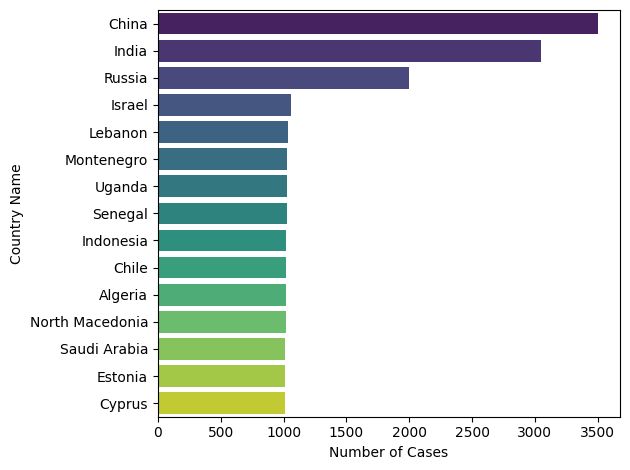

In [ ]:

# Count the number of 'cases' (Self_Experienced_MH == 1) per country
case_counts_by_country = df1['COUNTRYNAME'].value_counts().reset_index()
case_counts_by_country.columns = ['COUNTRYNAME', 'Number of Cases']

# Create the horizontal bar chart
sns.barplot(data=case_counts_by_country, x='Number of Cases', y='COUNTRYNAME', palette='viridis')
plt.ylabel('Country Name')
plt.tight_layout()
plt.show()



In [ ]:
df2 = pd.read_csv("/content/FILTERED_MENTAL_HEALTH_DATASET.csv")

In [ ]:
df2

# CORRELATION

In [ ]:
numerical_df1 = df1.select_dtypes(include=['int64','float64'])
numerical_df1.corr()

# BOXPLOT


In [ ]:
sns.boxplot(data = df1.select_dtypes(include = ['int64' , 'float64']))    #WITH DF1
plt.figure(figsize=(100 , 100))

plt.show()

# HEATMAPS

In [ ]:
sns.heatmap(df1.corr(numeric_only = True))

# OUTLIERS ANALYSIS

In [ ]:
num_cols = df1.select_dtypes(exclude = 'object')     #WITH DF1

In [ ]:
# Function to removce outlier from multiple columns
def remove_outliers_iqr_multi(df1, columns):
    df_clean = df1.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    for col in columns:
        sns.boxplot(y=df_clean[col])
        plt.title(f'Boxplot of {col} (Outliers Removed)')
        plt.show()
    return df_clean

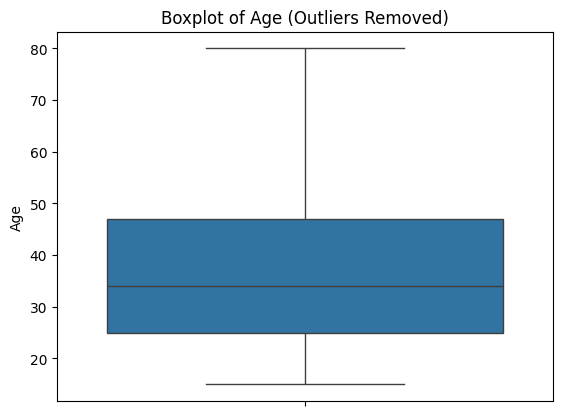

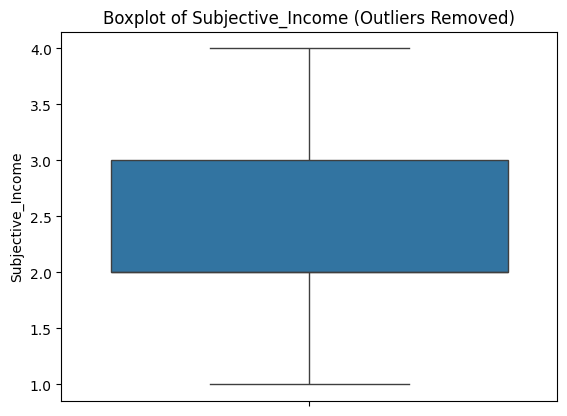

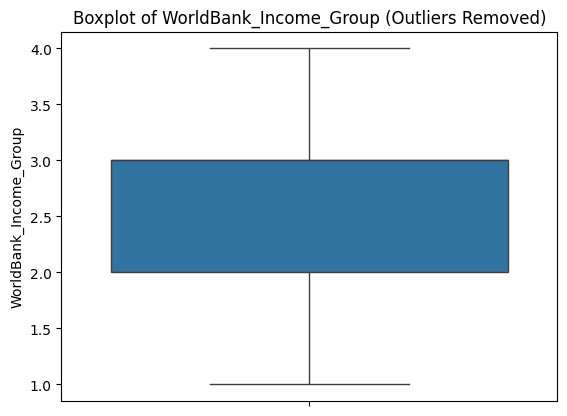

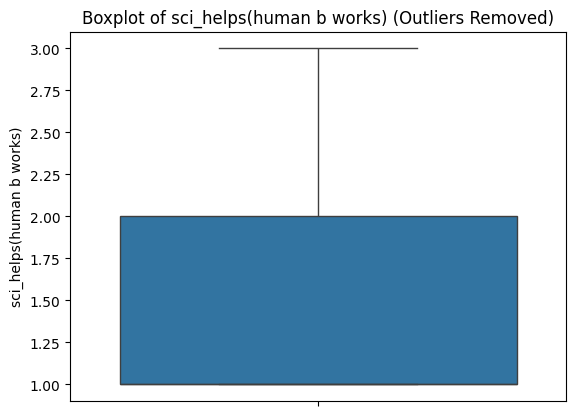

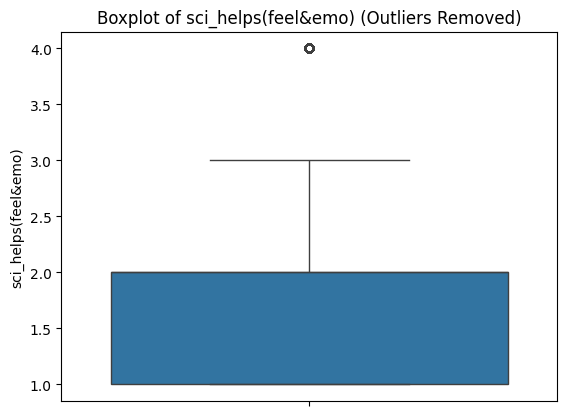

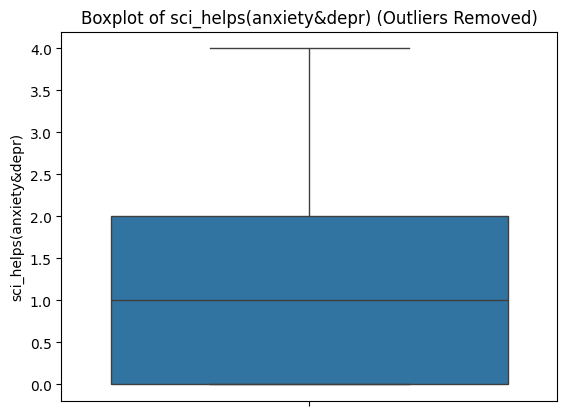

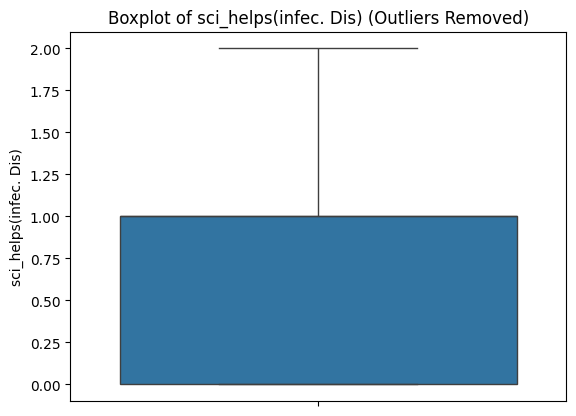

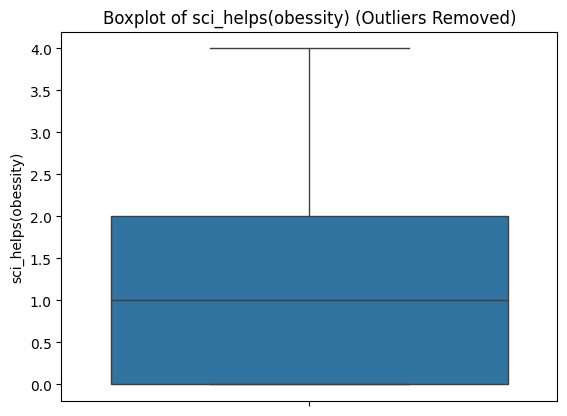

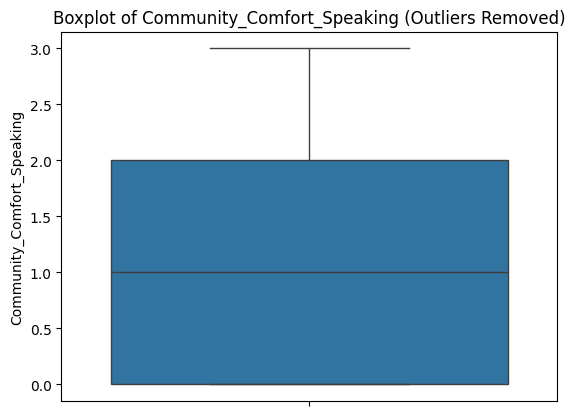

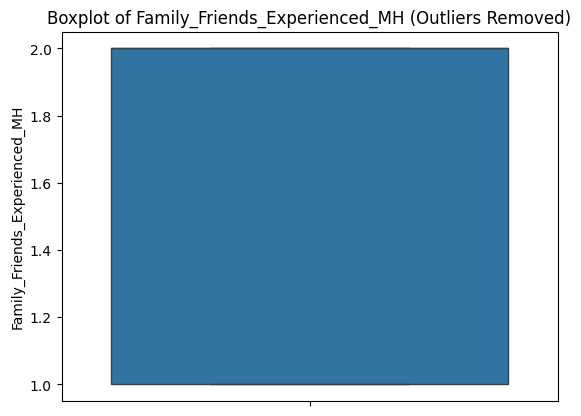

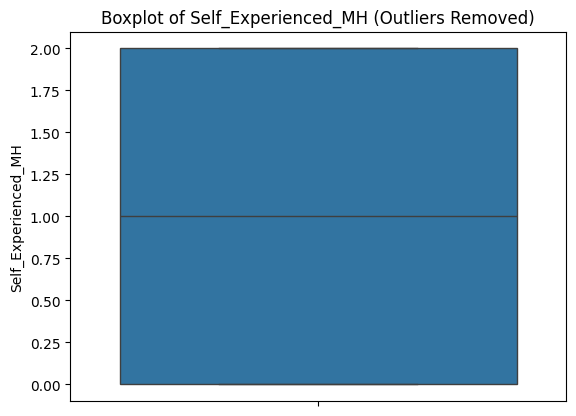

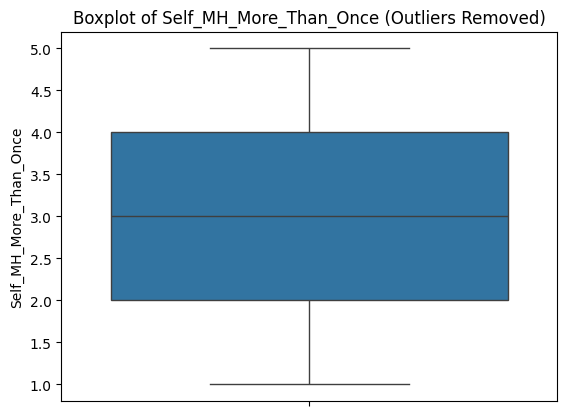

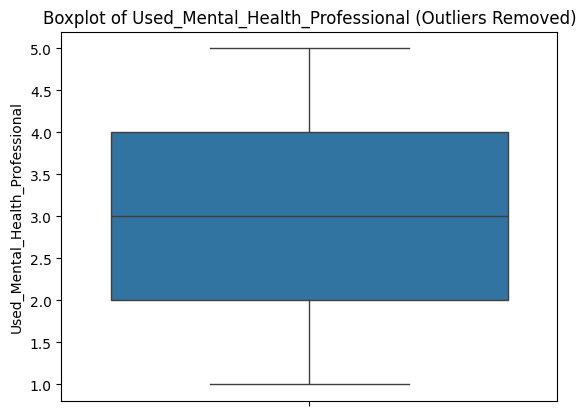

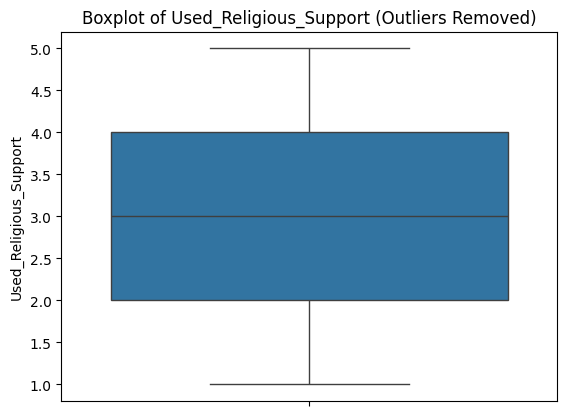

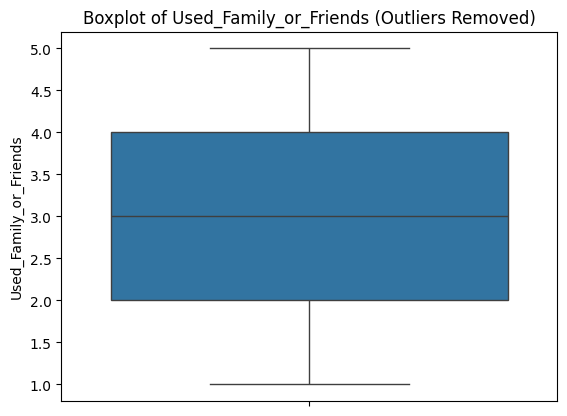

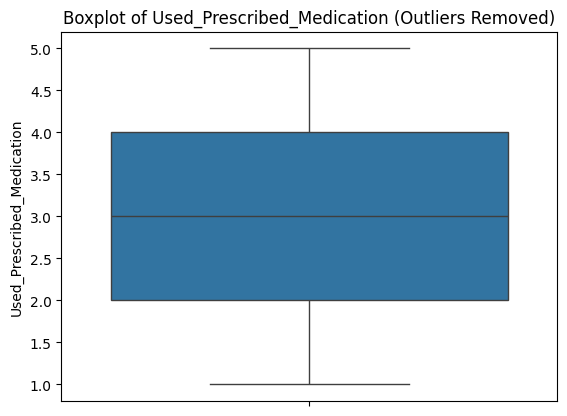

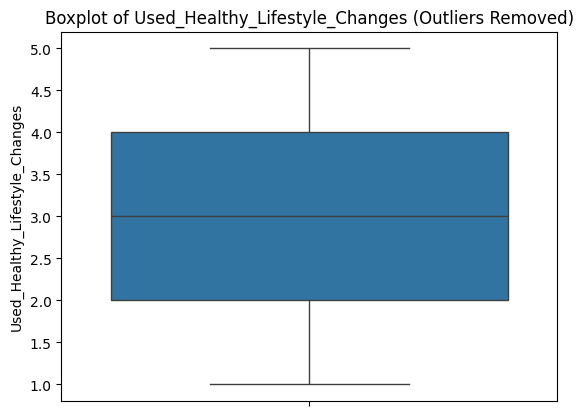

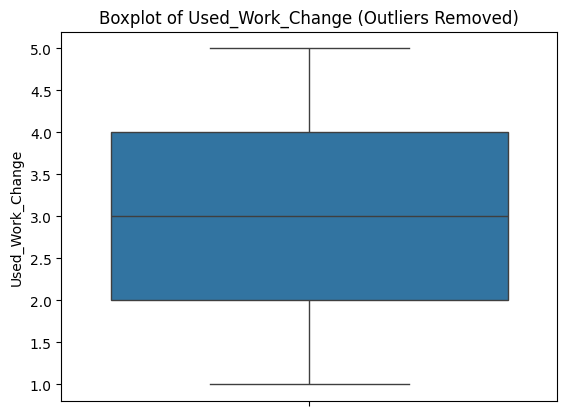

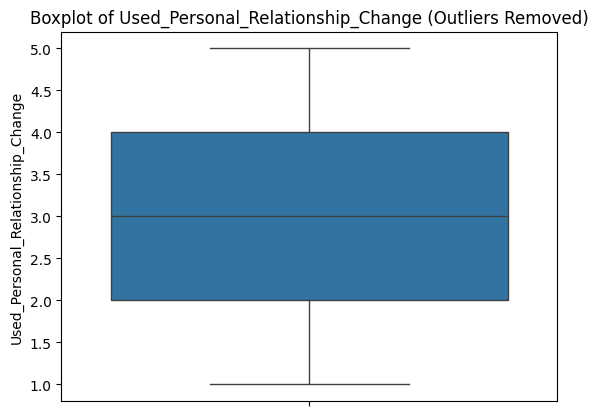

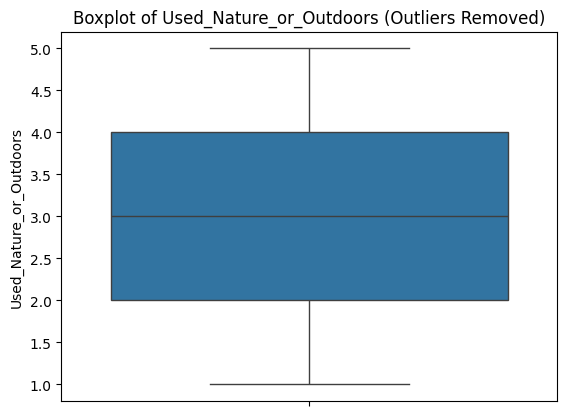

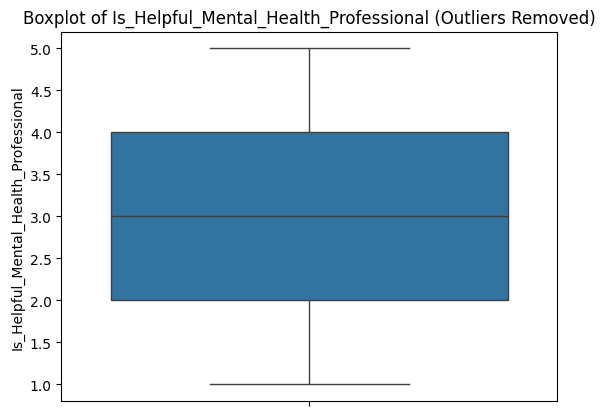

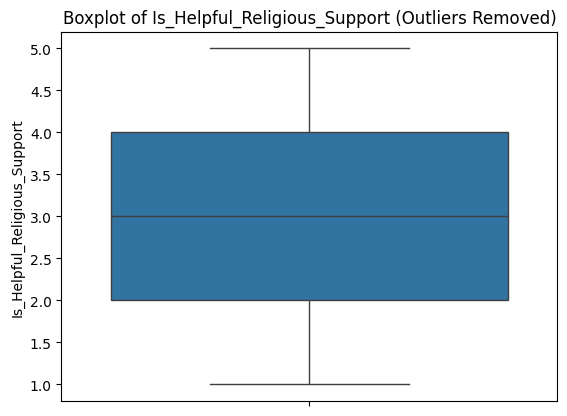

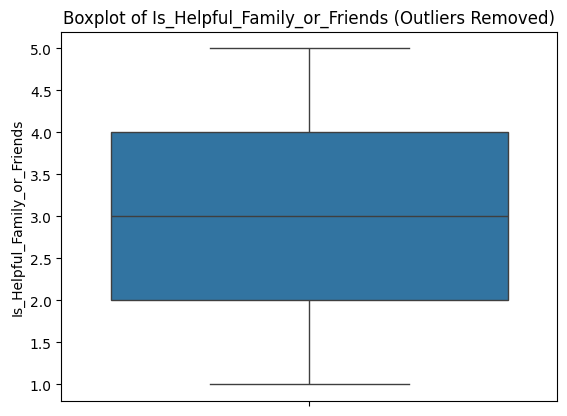

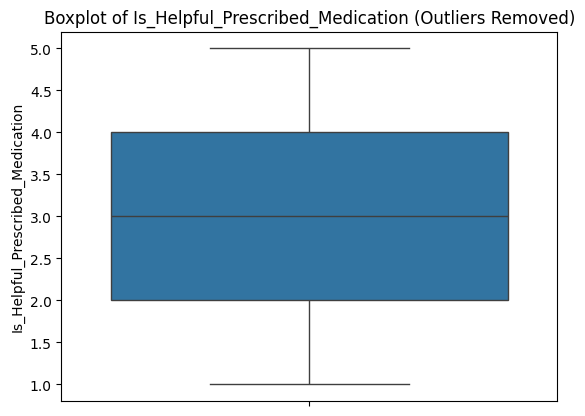

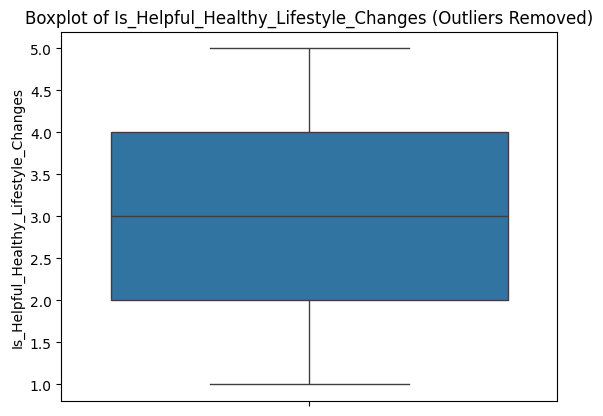

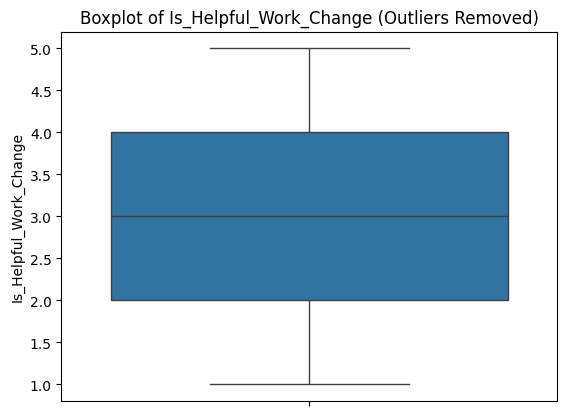

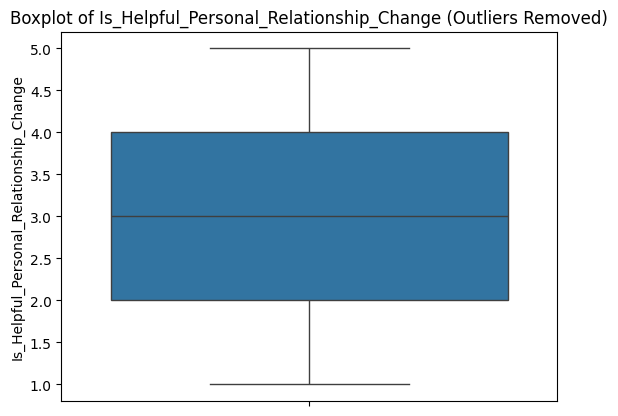

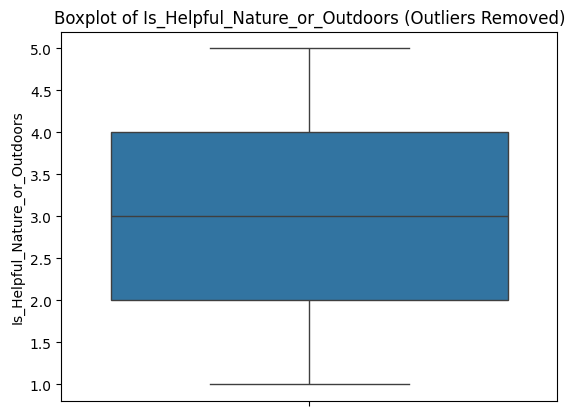

In [ ]:
df1 = remove_outliers_iqr_multi(df1, num_cols)

# LINEAR REGRESSION IN DATA FRAME

## label encoder

In [ ]:
from sklearn.preprocessing import LabelEncoder        #WITH DF1
le=LabelEncoder()

# Convert GovtFundResearch(depr) to numeric, coercing errors
df1['GovtFundResearch(depr)'] = pd.to_numeric(df1['GovtFundResearch(depr)'], errors='coerce')

cat_cols = df1.select_dtypes(include=['object']).columns

for col in cat_cols:
    df1[col]=le.fit_transform(df1[col])

In [ ]:
df1.head()

,COUNTRYNAME,Gender,Age,Household_Income,Subjective_Income,WorldBank_Income_Group,sci_helps(human b works),sci_helps(feel&emo),sci_helps(anxiety&depr),sci_helps(infec. Dis),...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
0,8,0,62,4,3,3,1,2,2,1,...,3,3,3,1,4,5,2,1,1,5
2,8,0,38,4,2,3,1,2,3,1,...,1,2,5,1,4,2,3,4,1,5
3,8,1,62,1,3,3,3,4,1,1,...,5,1,4,3,1,4,5,4,4,3
4,8,1,25,4,2,3,1,1,2,1,...,3,5,1,1,5,5,2,1,2,1
5,8,1,37,5,4,3,2,2,1,1,...,4,4,3,1,2,5,5,3,5,4


In [ ]:
df1.shape

(15129, 32)

# LOGISTIC REGRESSION


# model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
import numpy as np

X = df1.drop('Self_Experienced_MH', axis=1)
y = df1['Self_Experienced_MH']

numeric_cols = X.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy='mean')
X[numeric_cols] = imputer.fit_transform(X[numeric_cols])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy}")

print(classification_report(y_test, y_pred))

Model Accuracy: 0.9365499008592201
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1341
           1       0.83      0.68      0.75       417
           2       0.90      0.95      0.93      1268

    accuracy                           0.94      3026
   macro avg       0.91      0.88      0.89      3026
weighted avg       0.93      0.94      0.93      3026



# FEATURE SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [ ]:
x_train=sc.fit_transform(X_train)

In [ ]:
X_test=sc.transform(X_test)

In [ ]:
X_train

,COUNTRYNAME,Gender,Age,Household_Income,Subjective_Income,WorldBank_Income_Group,sci_helps(human b works),sci_helps(feel&emo),sci_helps(anxiety&depr),sci_helps(infec. Dis),...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
9952,7.0,1.0,53.0,2.0,3.0,4.0,2.0,2.0,2.0,1.0,...,1.0,3.0,2.0,2.0,5.0,1.0,2.0,5.0,2.0,2.0
10517,7.0,0.0,20.0,2.0,2.0,4.0,2.0,1.0,2.0,1.0,...,2.0,3.0,4.0,3.0,3.0,5.0,3.0,2.0,3.0,1.0
11397,14.0,1.0,60.0,2.0,3.0,1.0,1.0,1.0,1.0,1.0,...,5.0,4.0,4.0,5.0,4.0,5.0,3.0,3.0,3.0,1.0
8700,5.0,0.0,22.0,0.0,2.0,2.0,1.0,1.0,1.0,1.0,...,5.0,5.0,4.0,4.0,1.0,2.0,4.0,5.0,1.0,1.0
14400,11.0,0.0,28.0,2.0,1.0,3.0,2.0,2.0,0.0,0.0,...,1.0,3.0,3.0,5.0,4.0,3.0,5.0,3.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7942,5.0,1.0,16.0,5.0,4.0,2.0,1.0,3.0,2.0,2.0,...,2.0,5.0,1.0,5.0,5.0,5.0,4.0,1.0,2.0,5.0
18918,10.0,1.0,27.0,2.0,2.0,3.0,3.0,3.0,0.0,0.0,...,3.0,5.0,2.0,3.0,5.0,2.0,4.0,4.0,2.0,3.0
8270,5.0,0.0,21.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,...,1.0,1.0,3.0,2.0,1.0,2.0,1.0,4.0,2.0,2.0
1266,12.0,0.0,30.0,4.0,1.0,4.0,1.0,1.0,1.0,1.0,...,3.0,1.0,1.0,5.0,3.0,1.0,4.0,3.0,1.0,3.0


# MODEL BUILDING

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [ ]:
lr.fit(X_train,y_train)

LinearRegression()

# CHECK FOR OVERFITTING

In [ ]:
from sklearn.metrics import r2_score

# Calculate R-squared for training set
y_train_pred = lr.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
print(f"R-squared on training set: {r2_train}")

# Calculate R-squared for testing set
y_test_pred = lr.predict(X_test)
r2_test = r2_score(y_test, y_test_pred)
print(f"R-squared on testing set: {r2_test}")

# Check for overfitting
if r2_train > r2_test and (r2_train - r2_test) > 0.1:  # A difference of more than 0.1 can indicate overfitting
    print("The model might be overfitted.")
elif r2_train < r2_test:
    print("The model might be underfitted or the test set has less variance.")
else:
    print("The model does not appear to be significantly overfitted.")

R-squared on training set: 0.8237738016582973
R-squared on testing set: 0.744582970084565
The model does not appear to be significantly overfitted.


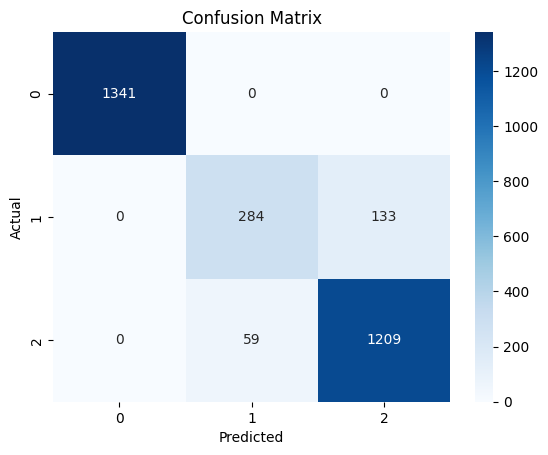

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap of the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Model Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1341
           1       1.00      1.00      1.00       417
           2       1.00      1.00      1.00      1268

    accuracy                           1.00      3026
   macro avg       1.00      1.00      1.00      3026
weighted avg       1.00      1.00      1.00      3026



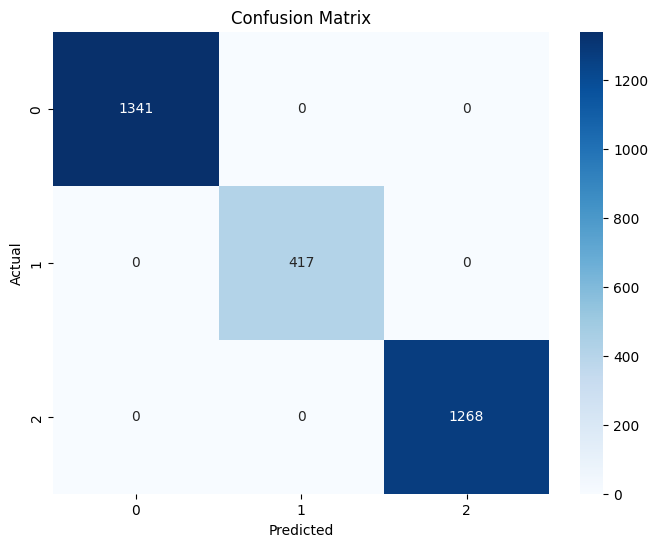

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import numpy as np

# Separate features (X) and target (y)
X = df1.drop('Self_Experienced_MH', axis=1)
y = df1['Self_Experienced_MH']

# Handle potential missing values in X (if any after outlier removal)
numeric_cols = X.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='mean')
X[numeric_cols] = imputer.fit_transform(X[numeric_cols])


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()